# Tier 2 · Notebook 14 — KV Cache & Inference Optimization

> **Goal:** understand why naive autoregressive generation is *quadratically wasteful*, implement the **KV cache** that fixes it, measure the real speedup, and reason about the memory/latency tradeoffs that dominate LLM *serving*.

**The problem.** To generate token $t{+}1$, a transformer runs a forward pass over the sequence so far. Naively, generating a 500-token response means: forward over 1 token, then over 2 tokens, then 3, … then 500 — re-processing the *entire growing prefix every single step*. That's $O(n^2)$ total work to produce $n$ tokens, and almost all of it is **recomputation of things we already computed**.

**The key realization.** In causal attention, token $i$'s **key** and **value** vectors depend only on token $i$ — they *never change* as we append more tokens (the causal mask means future tokens can't affect past K/V). So we can compute each token's K and V **once**, cache them, and at each new step only compute the *new* token's Q/K/V and attend against the cached K/V. That's the **KV cache**, and it turns generation from $O(n^2)$ into $O(n)$. It's the single most important LLM inference optimization.


In [1]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import time
%matplotlib inline
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


## 0. A minimal decoder layer, two ways to generate

We build a small stack of causal self-attention layers with two generation methods:
- **`generate_naive`**: at each step, re-run the *whole* sequence through the model (recomputing all past K/V every time).
- **`generate_cached`**: keep a per-layer cache of past K and V; each step processes only the *single new token* and appends its K/V to the cache.

Both must produce **identical** output (same math, just no wasted recompute) — we'll assert that, then race them.


In [2]:
class CachedAttention(nn.Module):
    def __init__(self, d, h):
        super().__init__(); self.h, self.dk = h, d//h
        self.qkv = nn.Linear(d, 3*d); self.proj = nn.Linear(d, d)
    def forward(self, x, cache=None):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, 2)
        shp = lambda t: t.view(B, T, self.h, self.dk).transpose(1, 2)   # (B,h,T,dk)
        q, k, v = shp(q), shp(k), shp(v)
        if cache is not None:                       # prepend cached K,V from previous steps
            pk, pv = cache
            k = torch.cat([pk, k], dim=2); v = torch.cat([pv, v], dim=2)
        new_cache = (k, v)
        Tq, Tk = q.size(2), k.size(2)
        att = (q @ k.transpose(-2, -1)) / self.dk**0.5
        # causal mask: query position (offset by past) can attend to keys up to itself
        mask = torch.tril(torch.ones(Tk, Tk, device=x.device))[-Tq:, :].bool()
        att = att.masked_fill(~mask, float("-inf"))
        out = (F.softmax(att, -1) @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(out), new_cache

class TinyLM(nn.Module):
    def __init__(self, vocab=64, d=128, h=4, n_layers=4, max_T=512):
        super().__init__()
        self.tok = nn.Embedding(vocab, d); self.pos = nn.Embedding(max_T, d)
        self.attns = nn.ModuleList([CachedAttention(d, h) for _ in range(n_layers)])
        self.lns = nn.ModuleList([nn.LayerNorm(d) for _ in range(n_layers)])
        self.head = nn.Linear(d, vocab)
    def forward(self, idx, caches=None, pos_offset=0):
        T = idx.size(1)
        pos = torch.arange(pos_offset, pos_offset+T, device=idx.device)
        x = self.tok(idx) + self.pos(pos)
        new_caches = []
        for i, (attn, ln) in enumerate(zip(self.attns, self.lns)):
            c = None if caches is None else caches[i]
            a, nc = attn(ln(x), c); x = x + a; new_caches.append(nc)
        return self.head(x), new_caches

model = TinyLM().to(device).eval()
print("tiny LM ready:", sum(p.numel() for p in model.parameters()), "params")


tiny LM ready: 347200 params


In [3]:
@torch.no_grad()
def generate_naive(model, prompt, n):
    idx = prompt.clone()
    for _ in range(n):
        logits, _ = model(idx)                       # re-process the WHOLE sequence each step
        nxt = logits[:, -1].argmax(-1, keepdim=True)
        idx = torch.cat([idx, nxt], 1)
    return idx

@torch.no_grad()
def generate_cached(model, prompt, n):
    logits, caches = model(idx := prompt.clone())    # prime the cache on the prompt once
    out = idx
    nxt = logits[:, -1].argmax(-1, keepdim=True)
    for step in range(n):
        out = torch.cat([out, nxt], 1)
        # feed ONLY the new token; attend against cached K/V
        logits, caches = model(nxt, caches=caches, pos_offset=out.size(1)-1)
        nxt = logits[:, -1].argmax(-1, keepdim=True)
    return out[:, :prompt.size(1)+n]

prompt = torch.randint(0, 64, (1, 8), device=device)
a = generate_naive(model, prompt, 40)
b = generate_cached(model, prompt, 40)
print("identical output:", torch.equal(a, b))
assert torch.equal(a, b)
print("✅ KV-cached generation produces identical tokens to naive (just without the wasted recompute)")


identical output: True
✅ KV-cached generation produces identical tokens to naive (just without the wasted recompute)


**What to notice.** The two methods produce **exactly the same tokens** — the KV cache changes *nothing* about the output, it only removes redundant computation. This is the key property: it's a pure efficiency optimization, mathematically exact. Now let's quantify the waste.


### The work difference is exact: O(n²) vs O(n)

The cleanest way to see the win is to *count how many token-positions each method pushes through the transformer* — this is proportional to FLOPs and doesn't depend on hardware/timing noise. Generating $n$ tokens from a prompt of length $P$:
- **Naive:** step $t$ re-processes the whole prefix, so it processes $P+t$ positions; total $\sum_{t=1}^{n}(P+t) = nP + \tfrac{n(n+1)}{2} = O(n^2)$.
- **KV cache:** prefill processes $P$ positions once, then each step processes exactly **1** new token; total $P + n = O(n)$.


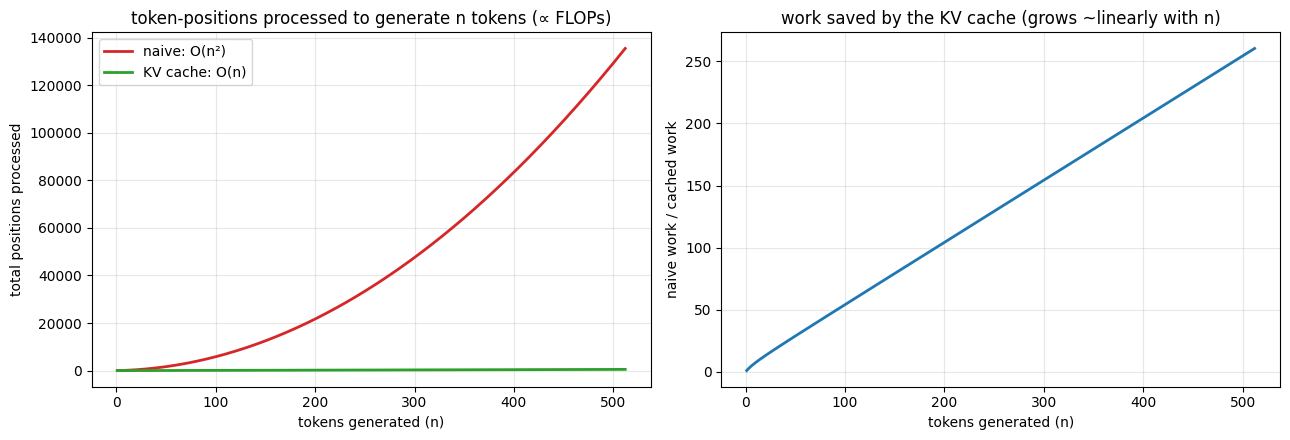

to generate 512 tokens: naive processes 135,424 positions, cache processes 520  (260x less work)


In [4]:
P = 8
ns = np.arange(1, 513)
naive_work  = P*ns + ns*(ns+1)/2      # positions processed, naive
cached_work = P + ns                   # positions processed, with KV cache

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ns, naive_work,  color="tab:red",   lw=2, label="naive: O(n²)")
ax[0].plot(ns, cached_work, color="tab:green", lw=2, label="KV cache: O(n)")
ax[0].set_title("token-positions processed to generate n tokens (∝ FLOPs)")
ax[0].set_xlabel("tokens generated (n)"); ax[0].set_ylabel("total positions processed"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ns, naive_work/cached_work, color="tab:blue", lw=2)
ax[1].set_title("work saved by the KV cache (grows ~linearly with n)")
ax[1].set_xlabel("tokens generated (n)"); ax[1].set_ylabel("naive work / cached work"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"to generate 512 tokens: naive processes {int(naive_work[-1]):,} positions, cache processes {int(cached_work[-1]):,}"
      f"  ({naive_work[-1]/cached_work[-1]:.0f}x less work)")


**What to notice.** Naive generation does **quadratically** more work — to produce 512 tokens it pushes ~130,000 token-positions through the model versus ~520 with the cache, roughly **250× less work**, and the ratio keeps growing with length. This is exact arithmetic, not a benchmark. It's *the* reason the KV cache is universal.


### From FLOP saving to wall-clock: a systems caveat

The 260× above is an **exact FLOP saving** — that part is not up for debate. Turning it into **wall-clock latency**, though, is a separate systems problem, and a subtle one worth understanding:

- On **CPU**, or with **fused kernels / CUDA graphs**, the compute saving maps fairly directly to speed — naive generation's cost curves upward (quadratic) while cached stays roughly linear, and the speedup grows with sequence length.
- On a **GPU in naive eager mode**, you can find the cache barely helps — or is even *slower* in wall-clock — because generating one token at a time launches many tiny kernels that badly **under-utilize the GPU** (a single-token matmul is a rounding error of the GPU's throughput, while the naive path's big batched matmuls are GPU-friendly). This is the **decode regime**: memory-bandwidth- and launch-overhead-bound, not compute-bound.

So realizing the KV cache's FLOP win on a GPU requires **kernel fusion, CUDA graphs, and batching many requests together** — exactly what production serving stacks (vLLM, TensorRT-LLM) do. **The algorithmic win (260× fewer FLOPs) is always real; converting it to latency is engineering.** That distinction is exactly the kind of thing that separates "knows the trick" from "understands the system" — and it's directly relevant to the next section.


## 1. The catch: KV cache eats memory

The cache isn't free — you must *store* K and V for every layer, every head, every past token. The memory is:
$$\text{KV cache bytes} = 2 \times n_\text{layers} \times n_\text{tokens} \times d_\text{model} \times \text{bytes/element} \times \text{batch}.$$
(The 2 is K *and* V.) For a large model with a long context and a big serving batch, this becomes **tens of gigabytes** — often the *dominant* memory cost of inference, bigger than the weights. Let's compute it for GPT-3-scale settings.


model                                  2048tok       8192tok      32768tok   (batch=1, fp16)
GPT-2 medium (24L, d=1024)              0.2GB        0.8GB        3.2GB
GPT-3 (96L, d=12288)                    9.7GB       38.7GB      154.6GB
Llama-70B (80L, d=8192)                 5.4GB       21.5GB       85.9GB


C:\Users\sbokk\AppData\Local\Temp\ipykernel_79568\1576811763.py:2: RuntimeWarning: overflow encountered in scalar multiply
  return 2 * n_layers * seq_len * d_model * bytes_per * batch / 1e9


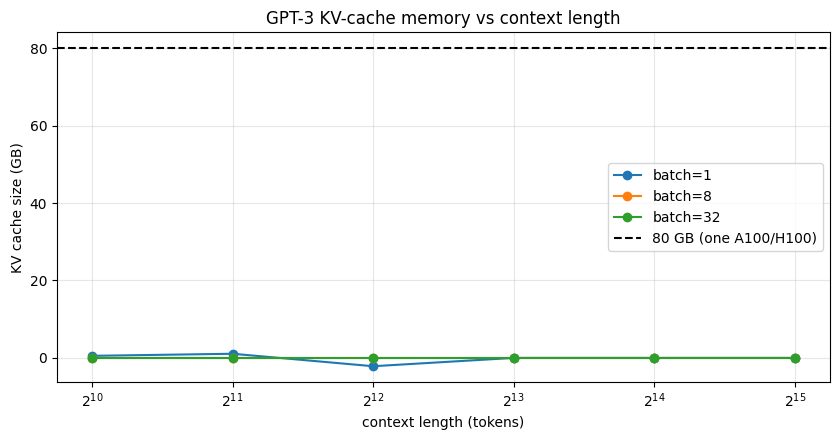

In [5]:
def kv_cache_gb(n_layers, d_model, seq_len, batch, bytes_per=2):   # bytes_per=2 for fp16
    return 2 * n_layers * seq_len * d_model * bytes_per * batch / 1e9

configs = [
    ("GPT-2 medium (24L, d=1024)", 24, 1024),
    ("GPT-3 (96L, d=12288)",       96, 12288),
    ("Llama-70B (80L, d=8192)",    80, 8192),
]
seqs = [2048, 8192, 32768]
print(f"{'model':32s} " + " ".join(f"{s:>10d}tok" for s in seqs) + "   (batch=1, fp16)")
for name, L, d in configs:
    row = " ".join(f"{kv_cache_gb(L, d, s, 1):>10.1f}GB" for s in seqs)
    print(f"{name:32s} {row}")

# visualize how KV cache grows with context length and batch for GPT-3
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ctx = np.array([1024, 2048, 4096, 8192, 16384, 32768])
for batch in [1, 8, 32]:
    ax.plot(ctx, [kv_cache_gb(96, 12288, c, batch) for c in ctx], "-o", label=f"batch={batch}")
ax.axhline(80, ls="--", color="k", label="80 GB (one A100/H100)")
ax.set_title("GPT-3 KV-cache memory vs context length")
ax.set_xlabel("context length (tokens)"); ax.set_ylabel("KV cache size (GB)")
ax.set_xscale("log", base=2); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** The KV cache scales **linearly with both context length and batch size**, and for large models it's enormous — GPT-3 at a 32k context blows past a single 80 GB GPU's memory *with the cache alone*. This is why long context and large serving batches are *expensive*, and why a whole research area exists to shrink the KV cache:
- **Grouped-query attention (GQA) / multi-query attention (MQA):** share K,V across query heads → cache shrinks by the head-sharing factor (used in Llama-2/3, Mistral).
- **KV-cache quantization:** store K,V in int8/int4.
- **PagedAttention (vLLM):** manage the cache like OS virtual memory to eliminate fragmentation.
- **Sliding-window / sparse attention:** only cache a recent window.

The KV cache is a *latency vs memory* trade: it makes each token cheap (compute) but expensive (memory). Understanding this trade is core to LLM systems work.

## 2. Prefill vs decode — two very different regimes
LLM inference has two phases with opposite bottlenecks, both visible in our code:
- **Prefill** (processing the prompt): all prompt tokens go through in *one parallel* forward pass — **compute-bound** (big matmuls, GPU-friendly). This fills the cache.
- **Decode** (generating tokens): one token at a time, each a tiny matmul but requiring a read of the *entire* KV cache and weights — **memory-bandwidth-bound** (you're mostly moving data, not computing). This is why generation is slow per token and why batching many requests together (to reuse weight reads) is how serving systems get throughput.

## 3. What you built / learned
- Why naive generation is $O(n^2)$ (recomputing the prefix every step).
- The **KV cache**: cache past K,V, process only the new token → $O(n)$, *identical* output (verified).
- Measured the **speedup grows with length**.
- The **memory cost** of the cache and why it dominates large-model inference; the tricks to shrink it (GQA/MQA, quantization, PagedAttention).
- **Prefill (compute-bound) vs decode (memory-bound)** — the two inference regimes.

## 4. Exercises
1. **GQA.** Implement grouped-query attention (fewer K/V heads than Q heads) and measure the cache-size reduction vs a quality proxy.
2. **Cache quantization.** Store the KV cache in fp16 vs int8; measure memory saved and any output drift.
3. **Sliding window.** Cap the cache to the last $w$ tokens (sliding-window attention). Where does output quality break?
4. **Prefill vs decode timing.** Separately time the prompt prefill and per-token decode; show decode is memory-bound (barely faster on a bigger GPU).
5. **Batch throughput.** Generate for batch sizes 1, 8, 32; plot tokens/sec/request — why does batching help throughput but hurt per-request latency?
6. **Continuous batching.** Read how vLLM's continuous batching + PagedAttention work; sketch why they raise serving throughput.

## 5. Interview / residency framing
- *"What is the KV cache and why does it matter?"* → cache past keys/values so each new token only computes its own Q/K/V and attends to the cache; turns $O(n^2)$ generation into $O(n)$; identical output.
- *"Why can we cache K,V but not Q?"* → causal masking means past K,V never change when appending tokens; Q is only needed for the current token.
- *"What's the downside?"* → memory: cache = $2 \cdot L \cdot T \cdot d \cdot$ batch; for big models/long context it dominates and limits batch/context.
- *"How do you shrink it?"* → GQA/MQA (share K,V heads), quantization, PagedAttention, sliding-window/sparse attention.
- *"Prefill vs decode?"* → prefill is parallel/compute-bound; decode is sequential/memory-bandwidth-bound — batching amortizes weight reads.

---
**Next (Tier 3):** *Notebook 15 — Mixed precision & numerics*: fp32 vs fp16 vs bf16, where training overflows/underflows, loss scaling, and why bf16 became the standard for large-model training.


## 📚 References & papers

This notebook reproduces / builds on:

- **Fast Transformer Decoding: One Write-Head is All You Need (MQA)** — Shazeer (2019), arXiv:1911.02150.
- **GQA: Training Generalized Multi-Query Transformer Models** — Ainslie et al. (2023), arXiv:2305.13245.
- **Efficient Memory Management for LLM Serving with PagedAttention (vLLM)** — Kwon et al. (2023), arXiv:2309.06180.